<a href="https://colab.research.google.com/github/diegogr98/Diego-Gutierrez-Astronomy/blob/main/gravitational_waves.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Autor:** Diego gutierrez

**objetivo:** Simular una onda gravitacional real

# Punto 1: forma de onda gravitacional para la fuente GW170814

**i) Aproximación cuadrupolar de la perturbación métrica:**

 Een este punto se  desarrolla la **forma de onda gravitacional en la región lejana** (*far field*) para la fuente **GW170814**, un sistema binario de dos agujeros negros cuya señal fue detectada el 14 de agosto de 2017 por la red de detectores LIGO–Virgo.


De acuerdo con los apuntes de *Relatividad y Gravitación* del profesor, la perturbación métrica en el régimen lejano se escribe como:

$$
\bar{h}^{ij}_\mathrm{far}(t,\vec{r})=\frac{2G}{c^4\,r}\,\ddot{I}^{ij}(t - r/c),
$$

donde $I^{ij}$ es el segundo momento de masa de la fuente.

El momento cuadrupolar para un sistema binario con componentes $(m_1, m_2)$ en órbita circular puede expresarse analíticamente en términos de la frecuencia orbital $\omega$ y la masa reducida del sistema.

<br>

---

**ii) Polarización de la onda**

La perturbación métrica físicamente observable corresponde a la proyección
transversal y sin traza (TT) del tensor $\bar h^{ij}$. Para una onda que se
propaga en la dirección $z$, la métrica perturbada en el gauge TT toma la
forma

$$
h^{\mathrm{TT}}_{ij}(t)
=
\begin{pmatrix}
h_+(t) & h_\times(t) & 0 \\
h_\times(t) & -h_+(t) & 0 \\
0 & 0 & 0
\end{pmatrix}.
$$

Esto define las dos polarizaciones independientes de la onda gravitacional:
la polarización **plus** ($+$) y la polarización **cross** ($\times$).

$$
\begin{aligned}
h_+(t) &= A(t)\,\big(1+\cos^2\Theta\big)\,\cos\big(2\Phi(t)\big),\\[6pt]
h_\times(t) &= -2\,A(t)\,\cos\Theta\,\sin\big(2\Phi(t)\big),
\end{aligned}
$$

donde:

- $A(t) = \dfrac{2G^{5/3}}{c^4}\,\dfrac{\mathcal{M}^{5/3}\,\omega^{2/3}(t)}{R}$ es la amplitud característica.
- $\mathcal{M} = \mu^{3/5} M^{2/5}$ es la **masa chirp** del sistema  
- $\Theta$ es el ángulo de inclinación orbital respecto a la línea de visión.  
- $\Phi(t)$ es la fase orbital acumulada.  
- $R$ es la distancia a la fuente.  

Estas expresiones resultan de analizar la segunda derivada temporal del tensor cuadrupolar y proyectar la perturbación en la base TT, tal como se detalla en la síntesis general de emisión de ondas gravitacionales del texto guía del curso.

<br>

---
**iii) Evaluación en el ISCO**

El *Innermost Stable Circular Orbit* (ISCO) establece un radio característico de la órbita más interna antes de la fusión, que en términos de masa total $M=m_1+m_2$ se aproxima por:

$$
r_{\mathrm{ISCO}} \approx 6\,\frac{GM}{c^2}.
$$

La frecuencia orbital en el ISCO es:

$$
\omega_{\mathrm{ISCO}} = \sqrt{\frac{GM}{r^3_{\mathrm{ISCO}}}},
$$

y la frecuencia de las ondas gravitacionales dominantes es $f_{\rm GW} = \omega_{\mathrm{ISCO}}/\pi$.

Al evaluar las expresiones de $h_+(t)$ y $h_\times(t)$ en torno a $t_{\rm ISCO}$ usando esta frecuencia y la masa chirp se obtiene la **forma de onda característica**.


<br>

---
**iv) Parámetros**

Para GW170814, los parámetros relevantes extraídos de la observación son:  
- $m_1\simeq 30.5\,M_\odot$, $m_2\simeq 25.3\,M_\odot$  
- Distancia de luminosidad $R \simeq 540$ Mpc.

Estos valores sirven de entrada para calcular la masa chirp y la frecuencia característica en ISCO utilizadas en la simulación de $h_+(t)$ y $h_\times(t)$.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timezone

In [ ]:
# Constantes físicas
G = 6.67430e-11
c = 299792458
M_sun = 1.98847e30
parsec = 3.0857e16        # 1 parsec en metros

# Datos del evento GW170814
m1 = 30.5 * M_sun
m2 = 25.3 * M_sun
D = 540 * 1e6 * parsec

# Masa total y masa reducida
M = m1 + m2
mu = (m1*m2)/M

# Masa "chirp"
masa_c = mu**(3/5)*M**(2/5)

# Radio aproximado del ISCO para órbita circular
r_isco = 6 * G * M / c**2

# Frecuencia orbital en el ISCO
omega_isco = np.sqrt(G * M / r_isco**3)

f_gw_isco = omega_isco/np.pi

In [ ]:
# Tiempo alrededor de ISCO
t_final = 0.01   # segundos antes de la fusión
t = np.linspace(-t_final, 0, 10000)

# Fase orbital (aproximada)
phi = 2*np.pi * f_gw_isco * (t + t_final)

# Ángulo de inclinación (asumimos observación en el eje de rotación)
Theta = 0.0

# Amplitud de la onda
A = (2*G**(5/3)/c**4)*masa_c**(5/3)* (omega_isco**(2/3)) / D

# Polarizaciones h_plus y h_cross
h_plus  = A * (1 + np.cos(Theta)**2)* np.cos(2*phi)
h_cross = -2*A*np.cos(Theta)*np.sin(2*phi)

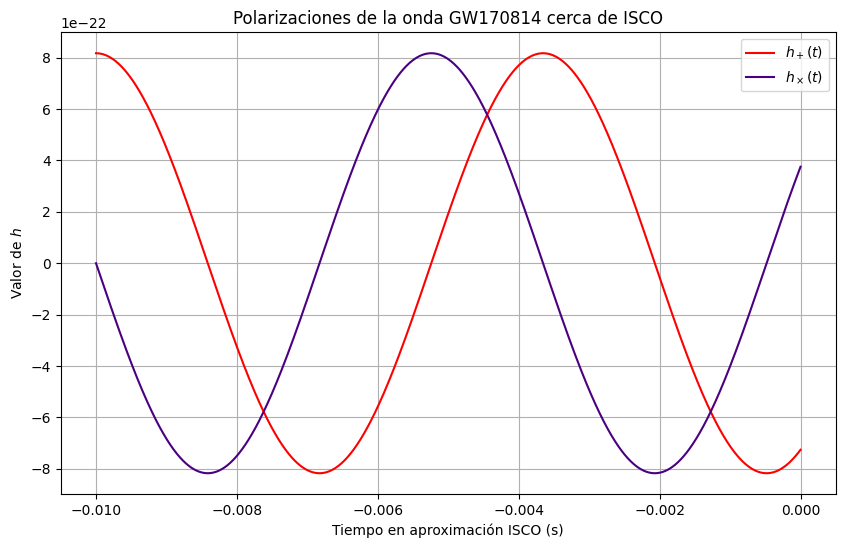

In [ ]:
# Gráficas
plt.figure(figsize=(10,6))
plt.plot(t, h_plus, label='$h_+(t)$',color='red')
plt.plot(t, h_cross, label='$h_\\times(t)$',color='indigo')
plt.xlabel('Tiempo en aproximación ISCO (s)')
plt.ylabel('Valor de $h$')
plt.title('Polarizaciones de la onda GW170814 cerca de ISCO')
plt.legend()
plt.grid()
plt.show()


# Punto 2: Intensidad y magnitud de la señal

---
**i) Cálculo de la potencia emitida en ondas gravitacionales (cuadrupolo)**

La potencia total emitida en ondas gravitacionales por una fuente aislada, en
la aproximación cuadrupolar, viene dada por:

$$
L_{\rm GW} \;=\; \frac{G}{5\,c^5}\,\langle \dddot{Q}^{ij}\,\dddot{Q}_{ij} \rangle,
$$

donde $Q^{ij}$ es el tensor del momento cuadrupolar de masa de la fuente y
los puntos denotan derivadas temporales.

<br>

En el sistema de referencia del centro de masas, el tensor cuadrupolar
(reducido y sin traza) está dado por

$$
Q^{ij}(t)
=
\mu\left(x^i x^j - \frac{1}{3}\delta^{ij} r^2\right),
$$

donde $ \mu = \frac{m_1 m_2}{M} $ es la masa reducida y $ r $ es la separación orbital.

---
**ii) Movimiento orbital circular**

Se asume una órbita circular en el plano $xy$:

$$
\begin{aligned}
x(t) &= a\cos(\omega t),\\
y(t) &= a\sin(\omega t),\\
z(t) &= 0,
\end{aligned}
$$

con radio orbital constante $a$ y frecuencia angular $\omega$.
En este caso,

$$
r^2 = x^2 + y^2 = a^2.
$$

---

**ii) Componentes del cuadrupolo**

Las componentes no nulas del tensor cuadrupolar son:

$$
\begin{aligned}
Q^{11} &= \mu\left(a^2\cos^2\omega t - \frac{1}{3}a^2\right),\\
Q^{22} &= \mu\left(a^2\sin^2\omega t - \frac{1}{3}a^2\right),\\
Q^{12} &= Q^{21} = \mu a^2 \cos\omega t\,\sin\omega t.
\end{aligned}
$$

Usando identidades trigonométricas, se obtiene

$$
\begin{aligned}
Q^{11} &= \mu a^2\left(\frac{1}{6} + \frac{1}{2}\cos 2\omega t\right),\\
Q^{22} &= \mu a^2\left(\frac{1}{6} - \frac{1}{2}\cos 2\omega t\right),\\
Q^{12} &= \frac{1}{2}\mu a^2 \sin 2\omega t.
\end{aligned}
$$

Solo los términos oscilantes contribuyen a la radiación gravitacional.

---

**iv) Derivadas temporales del cuadrupolo**

$$
\begin{aligned}
\dot{Q}^{11} &= -\mu a^2 \omega \sin 2\omega t,\\
\dot{Q}^{22} &= +\mu a^2 \omega \sin 2\omega t,\\
\dot{Q}^{12} &= \mu a^2 \omega \cos 2\omega t.
\end{aligned}
$$

<br>

$$
\begin{aligned}
\ddot{Q}^{11} &= -2\mu a^2 \omega^2 \cos 2\omega t,\\
\ddot{Q}^{22} &= +2\mu a^2 \omega^2 \cos 2\omega t,\\
\ddot{Q}^{12} &= -2\mu a^2 \omega^2 \sin 2\omega t.
\end{aligned}
$$

<br>

$$
\begin{aligned}
\dddot{Q}^{11} &= +4\mu a^2 \omega^3 \sin 2\omega t,\\
\dddot{Q}^{22} &= -4\mu a^2 \omega^3 \sin 2\omega t,\\
\dddot{Q}^{12} &= -4\mu a^2 \omega^3 \cos 2\omega t.
\end{aligned}
$$

---

**v) Desarrollo del producto cudrupolar**

La cantidad que entra en la fórmula de la potencia es

$$
\dddot{Q}^{ij}\dddot{Q}_{ij}
=
(\dddot{Q}^{11})^2
+
(\dddot{Q}^{22})^2
+
2(\dddot{Q}^{12})^2.
$$

Sustituyendo las expresiones anteriores:

<br>

$$
\dddot{Q}^{ij}\dddot{Q}_{ij}
=
(+4\mu a^2 \omega^3 \sin 2\omega t)^2
+
(-4\mu a^2 \omega^3 \sin 2\omega t)^2
+
2(-4\mu a^2 \omega^3 \cos 2\omega t)^2.
$$


$$
\dddot{Q}^{ij}\dddot{Q}_{ij}
=
32\,\mu^2 a^4 \omega^6(sin^2 (\omega t)+ cos^2 (\omega t) ).
$$

$$
\dddot{Q}^{ij}\dddot{Q}_{ij}
=
32\,\mu^2 a^4 \omega^6.
$$

Este resultado es constante, por lo que su promedio temporal coincide con el
valor instantáneo.

<br>

---

**vi) Luminosidad**

La luminosidad radiada viene dada por la fórmula del cuadrupolo:

$$
L_{\rm GW}
=
\frac{G}{5c^5}
\left\langle
\dddot{Q}^{ij}\dddot{Q}_{ij}
\right\rangle.
$$

Sustituyendo el resultado anterior:

$$
L_{\rm GW}
=
\frac{32}{5}
\frac{G}{c^5}
\mu^2 a^4 \omega^6.
$$

Usando la ley de Kepler para órbitas circulares,

$$
\omega^2 = \frac{GM}{a^3},
$$

se obtiene finalmente

$$
L_{\rm GW}
=
\frac{32}{5}
\frac{G^4}{c^5}
\frac{\mu^2 M^3}{a^5}
$$

Para estimar la luminosidad máxima del sistema, se evalúa esta expresión en
el radio de la órbita circular estable más interna (ISCO) asociada a la masa
total, dado por

$$
a_{\rm ISCO} = 6\,\frac{GM}{c^2}.
$$

Sustituyendo $a = a_{\rm ISCO}$ en la expresión de la luminosidad se obtiene

$$
L_{\rm GW}
=
\frac{32}{5}
\frac{G^4}{c^5}
\frac{\mu^2 M^3}{(6GM/c^2)^5}.
$$

Desarrollando el denominador,

$$
L_{\rm GW}
=
\frac{32}{5}
\frac{G^4}{c^5}
\frac{\mu^2 M^3 c^{10}}{(6GM)^5}.
$$

y simplificando potencias de $G$, $M$ y $c$, resulta finalmente

$$
\boxed{
L_{\rm GW}
=
\frac{32}{5}
\frac{c^5}{G}
\left(\frac{\mu}{M}\right)^2
\frac{1}{6^5}
}.
$$

Esta expresión muestra que la luminosidad gravitacional máxima está fijada
por la escala relativista $c^5/G$, modulada únicamente por el cociente de
masas $(\mu/M)^2$.



In [ ]:
# Luminosidad en ISCO
L_GW = (32/5) * (c**5/G) * (mu/M)**2 / 6**5

print(f"\nLuminosidad GW en ISCO: {L_GW:.3e} W")
print(f"\nEquivalente en soles: {L_GW / 3.828e26 : .3e}")

# Brillo (flux) en la Tierra

F_GW = L_GW / (4*np.pi*D**2)
print(f"\nFlujo GW en la Tierra: {F_GW:.3e} W/m^2")

# Constantes solares
L_sun = 3.828e26       # W
M_sun_abs = 4.83       # magnitud absoluta del Sol

# Magnitud absoluta equivalente
M_GW = M_sun_abs - 2.5*np.log10(L_GW / L_sun)

# Magnitud aparente equivalente
m_GW = M_GW + 5*np.log10(D/(10*parsec))

print(f"\nMagnitud absoluta equivalente: {M_GW:.3f}")
print(f"\nMagnitud aparente equivalente: {m_GW:.3f}")



Luminosidad GW en ISCO: 1.834e+48 W

Equivalente en soles:  4.791e+21

Flujo GW en la Tierra: 5.257e-04 W/m^2

Magnitud absoluta equivalente: -49.371

Magnitud aparente equivalente: -10.709


La magnitud equivalente obtenida corresponde a la luminosidad instantánea
máxima del sistema en el ISCO. Esta emisión ocurre durante un intervalo
temporal extremadamente corto y no representa una fuente persistente en el tiempo.


#Punto 3: Simulación de la señal producida en el detector de Handford

En este punto se determina la posición aparente de la fuente de ondas
gravitacionales en el cielo local del detector Handford en el momento de la
detección, y a partir de ella se construyen los tensores de polarización
que permiten proyectar la onda gravitacional sobre el detector de LIGO.

---

**i) Tiempo sidéreo: referencia rotacional de la Tierra**

Las coordenadas ecuatoriales de una fuente (ascensión recta $\alpha$ y
declinación $\delta$) están definidas con respecto a un sistema inercial
ligado a las estrellas. Sin embargo, el detector está fijo a la Tierra, que
rota. Para relacionar ambos sistemas es necesario introducir el **tiempo
sidéreo**.

Se toma como referencia la época estándar J2000.0:

$$
t_{\mathrm{J2000}} = \text{2000-01-01 12:00 UTC}
$$

El número de días transcurridos desde entonces es:

$$
d = \frac{t_{\mathrm{UTC}} - t_{\mathrm{J2000}}}{86400}
$$

Este valor mide cuánto ha rotado la Tierra desde J2000.

<br>

Para un detector situado a longitud geográfica $\lambda$ (positiva al
Este), el **tiempo sidéreo local y en Greenwich** está dado por las expresiones:

$$
\theta_{\mathrm{LST}} = \theta_{\mathrm{GST}} + \lambda
$$

$$
\theta_{\mathrm{GST}} =
280.46061837
+
360.98564736629\, d
\quad
$$



In [ ]:
# Fecha del evento (UTC)
t_utc = datetime(2017, 8, 14, 10, 30, 43, tzinfo=timezone.utc)


# Fecha de referencia J2000
t_J2000 = datetime(2000, 1, 1, 12, 0, 0, tzinfo=timezone.utc)

# Días desde J2000
d = (t_utc - t_J2000).total_seconds() / 86400.0


# Tiempo sidéreo en Greenwich
theta_GST_deg = 280.46061837 + 360.98564736629 * d
theta_GST_deg = theta_GST_deg % 360.0


# Longitud de Hanford
lambda_H = -119.408

# Latitud de Hanford
phi_deg = 46.455
phi_rad = np.deg2rad(phi_deg)

# Tiempo sidéreo local
theta_LST_deg = (theta_GST_deg + lambda_H) % 360.0
theta_LST_rad = np.deg2rad(theta_LST_deg)

theta_GST_deg, theta_LST_deg

(120.7194746946916, 1.3114746946915972)

---

**ii) De coordenadas ecuatoriales a horizontales**

La fuente GW170814 se caracteriza por su ascensión recta: $\alpha$, Declinación: $\delta$ además:

<br>

* El **ángulo horario** mide cuánto ha rotado la Tierra desde que la fuente
cruzó el meridiano local:

$$
H = \theta_{\mathrm{LST}} - \alpha
$$


* La **elevación** $h$ es el ángulo de la fuente sobre el horizonte local.
Usando trigonometría esférica:

$$
\sin h =
\sin\phi\,\sin\delta
+
\cos\phi\,\cos\delta\,\cos H
$$

donde $\phi$ es la latitud del detector. El ángulo $h$ se obtiene como:

$$
h = \arcsin(\sin h)
$$

* El **azimut** $A$ se mide en el plano horizontal, desde el norte hacia el
este. Se calcula mediante:

$$
A =
\arctan2\!\left(
-\sin H,
\sin\phi\,\cos H - \cos\phi\,\tan\delta
\right)
$$

In [ ]:
# Ascensión recta de la fuente (GW170814)
alpha_h = 3.7 # horas
alpha_deg = alpha_h * 15.0 # grados
alpha_rad = np.deg2rad(alpha_deg)

# Ángulo horario
H_rad = theta_LST_rad - alpha_rad

# Forzamos a rango [-pi, pi]
H_rad = np.arctan2(np.sin(H_rad), np.cos(H_rad))

np.rad2deg(H_rad)

np.float64(-54.1885253053084)

In [ ]:
# Declinación de la fuente
delta_deg = -44.0
delta_rad = np.deg2rad(delta_deg)

# Elevación
sin_h = (
    np.sin(phi_rad)*np.sin(delta_rad)
    + np.cos(phi_rad)*np.cos(delta_rad)*np.cos(H_rad)
)

h_rad = np.arcsin(sin_h)
h_deg = np.rad2deg(h_rad)

print(f"Elevación: {h_deg:.3f} grados")

Elevación: -12.330 grados


In [ ]:
# Azimut
A_rad = np.arctan2(
    -np.sin(H_rad),
    np.sin(phi_rad)*np.cos(H_rad) - np.cos(phi_rad)*np.tan(delta_rad)
)

A_deg = (np.rad2deg(A_rad) + 360) % 360
print(f"Azimut: {A_deg:.3f} grados")

Azimut: 36.664 grados


**iii) Dirección de propagación de la onda gravitacional**

Con el azimut $A$ y la elevación $h$, se define el **vector unitario de
propagación** de la onda (apuntando *desde la fuente hacia el detector*):

$$
\hat{k} =
\begin{pmatrix}
-\cos h \sin A \\
-\cos h \cos A \\
-\sin h
\end{pmatrix}
$$

Este vector define la dirección de llegada de la onda gravitacional en el
sistema local del detector.

---

**iv) Base de polarización de la onda**

La onda gravitacional es transversal, por lo que sus polarizaciones viven
en el plano perpendicular a $\hat{k}$.



Se construyen dos vectores ortonormales:

- Vector horizontal:
$$
\hat{p} =
\begin{pmatrix}
\cos A \\
-\sin A \\
0
\end{pmatrix}
$$

- Vector vertical (completa la base):
$$
\hat{q} = \hat{k} \times \hat{p}
$$


A partir de $\hat{p}$ y $\hat{q}$ se definen los tensores de polarización
estándar de la onda gravitacional:

$$
\mathbf{e}_+ = \hat{p}\otimes\hat{p} - \hat{q}\otimes\hat{q}
$$

$$
\mathbf{e}_\times = \hat{p}\otimes\hat{q} + \hat{q}\otimes\hat{p}
$$

Estos tensores permiten proyectar el tensor métrico perturbado
$h_{ij}$ sobre la geometría del detector y obtener la señal observada.



In [ ]:
# Convertimos a radianes
A_rad = np.deg2rad(A_deg)
h_rad = np.deg2rad(h_deg)

# Vector unitario de propagación de la onda
k_hat = np.array([
    -np.cos(h_rad) * np.sin(A_rad),
    -np.cos(h_rad) * np.cos(A_rad),
    -np.sin(h_rad)
])

k_hat

array([-0.5833462 , -0.78364942,  0.21354341])

In [ ]:
# Vector p (horizontal)
p_hat = np.array([
    np.cos(A_rad),
    -np.sin(A_rad),
    0.0
])

# Vector q (completa la base ortonormal)
q_hat = np.cross(k_hat, p_hat)

# Normalizamos
p_hat /= np.linalg.norm(p_hat)
q_hat /= np.linalg.norm(q_hat)

# Tensores de polarización
e_plus = np.outer(p_hat, p_hat) - np.outer(q_hat, q_hat)
e_cross = np.outer(p_hat, q_hat) + np.outer(q_hat, p_hat)

e_plus, e_cross

(array([[ 0.62718912, -0.50082272, -0.12456974],
        [-0.50082272,  0.32721009, -0.16734317],
        [-0.12456974, -0.16734317, -0.95439921]]),
 array([[ 0.20456639,  0.06126482,  0.78364942],
        [ 0.06126482, -0.20456639, -0.5833462 ],
        [ 0.78364942, -0.5833462 ,  0.        ]]))

In [ ]:
# Orientaciones de los brazos (grados de Norte a Este)
gamma_x = np.deg2rad(36.0)
gamma_y = np.deg2rad(126.0)

u_hat = np.array([
    np.sin(gamma_x),
    np.cos(gamma_x),
    0.0
])

v_hat = np.array([
    np.sin(gamma_y),
    np.cos(gamma_y),
    0.0
])

u_hat, v_hat


(array([0.58778525, 0.80901699, 0.        ]),
 array([ 0.80901699, -0.58778525,  0.        ]))

In [ ]:
# Tensor del detector
D = 0.5 * (np.outer(u_hat, u_hat) - np.outer(v_hat, v_hat))

# Factores de antena
F_plus = np.tensordot(D, e_plus, axes=2)
F_cross = np.tensordot(D, e_cross, axes=2)

F_plus, F_cross

(array(-0.52266002), array(-0.00494819))

Finalmente, el detector interferométrico no mide directamente las
polarizaciones individuales de la onda gravitacional, sino una
combinación lineal de ellas determinada por la geometría del detector y
la dirección de llegada de la onda. El strain efectivo medido por el
detector se expresa como:

$$
h_{\mathrm{det}}(t)
=
F_+(\theta,\phi,\psi)\,h_+(t)
+
F_\times(\theta,\phi,\psi)\,h_\times(t),
$$

donde $F_+$ y $F_\times$ son las funciones patrón del detector,
calculadas en el pumto anterior a partir de los tensores de polarización y la orientación de los brazos del interferómetro.


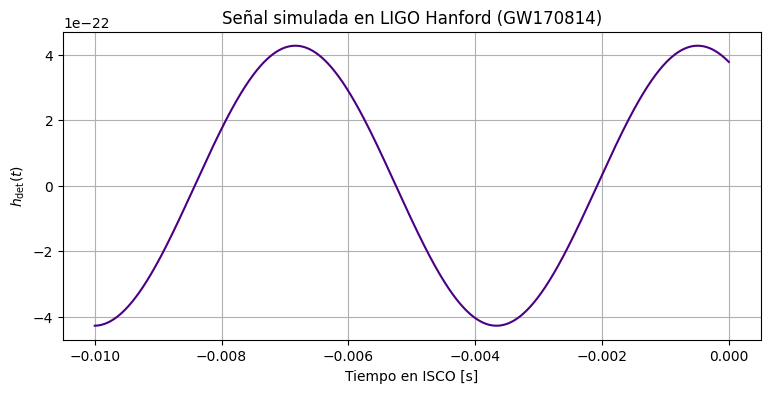

In [ ]:
# Señal del detector
h_det = F_plus * h_plus + F_cross * h_cross

# Gráfica
plt.figure(figsize=(9,4))
plt.plot(t, h_det, color="indigo")
plt.xlabel("Tiempo en ISCO [s]")
plt.ylabel(r"$h_{\mathrm{det}}(t)$")
plt.title("Señal simulada en LIGO Hanford (GW170814)")
plt.grid()
plt.show()


La señal gravitacional obtenida en este trabajo corresponde a una
aproximación cuasi–estacionaria del sistema binario en el ISCO,
en la cual la frecuencia orbital y la amplitud de la onda se
mantienen constantes. Bajo esta suposición, la forma de la señal
resulta aproximadamente senoidal, en contraste con la señal tipo
*chirp* observada por LIGO, que presenta un aumento progresivo de
frecuencia y amplitud.

A pesar de estas diferencias, el orden de magnitud es consistente con el
valor observado experimentalmente. Esto confirma que la teoría
de emisión de ondas gravitacionales basada en el cuadrupolo
describe adecuadamente la intensidad de la radiación emitida por
sistemas binarios compactos, incluso bajo aproximaciones
simplificadas.

La inclusión de la evolución temporal de la órbita y efectos
post–newtonianos permitiría reproducir con mayor fidelidad la
señal completa detectada por LIGO, lo cual queda fuera del alcance
del presente trabajo.


## Declaración de uso IAs.

*Declaro que la mayor parte del código contenido en este notebook es de mi propia autoría y no ha sido obtenido usando exclusivamente grandes modelos de lenguaje (LLMs o IAs)*.

*En casos excepcionales*:

- *Las celdas con gráficos complejos en `plotly` han sido elaboradas con el apoyo del modelo Gemini que viene incorporado en `Google Colab`*.
- *Cualquier uso adicional fue declarado en las celdas respectivas y en caso de que grandes porciones de código hayan sido extraídas de una IA, lo he indicado explícitamente agregando entre los comentarios el o los _prompts_ utilizados.*